In [1]:
# ─────────────────────────────────────────────
# 0. IMPORTS
# ─────────────────────────────────────────────
 
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ─────────────────────────────────────────────
# 1. CONFIGURATION
# ─────────────────────────────────────────────
 
DATASET_ROOT = "C:/Users/kavin/Downloads/FreshHarvest_Dataset/FRUIT-16K"
SPLITS_FILE  = "freshharvest_splits.pt"
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
NUM_WORKERS  = 0           # Must be 0 on Windows
RANDOM_SEED  = 42
 
# ── Hyperparameter grid to experiment with ─────────────────────
# Each dict is one experiment — feel free to add/change values
HYPERPARAMETER_CONFIGS = [
    {
        "name"        : "Baseline (Task 2 best)",
        "epochs"      : 30,
        "lr"          : 0.001,
        "optimizer"   : "SGD",
        "weight_decay": 0.0,       # No regularization
        "dropout"     : 0.0,       # No dropout
        "batch_norm"  : False,     # No batch norm
    },
    {
        "name"        : "BatchNorm + Dropout",
        "epochs"      : 30,
        "lr"          : 0.001,
        "optimizer"   : "SGD",
        "weight_decay": 0.0,
        "dropout"     : 0.5,       # Dropout 50%
        "batch_norm"  : True,      # Batch normalization
    },
    {
        "name"        : "Weight Decay + BatchNorm",
        "epochs"      : 30,
        "lr"          : 0.001,
        "optimizer"   : "SGD",
        "weight_decay": 1e-4,      # L2 regularization
        "dropout"     : 0.0,
        "batch_norm"  : True,
    },
    {
        "name"        : "Full Regularization (Adam)",
        "epochs"      : 30,
        "lr"          : 0.0005,    # Lower lr for Adam
        "optimizer"   : "Adam",
        "weight_decay": 1e-4,
        "dropout"     : 0.5,
        "batch_norm"  : True,
    },
]
 
# ── Early stopping patience ────────────────────────────────────
EARLY_STOP_PATIENCE = 7    # Stop if val acc doesn't improve for 7 epochs
 
BINARY_NAMES = ["Fresh", "Spoiled"]
BINARY_LABEL = {"F": 0, "S": 1}
FRUIT_NAMES  = [
    "Banana", "Lemon", "Lulo", "Mango",
    "Orange", "Strawberry", "Tamarillo", "Tomato"
]
 
# ── Device ─────────────────────────────────────────────────────
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = device.type == "cuda"
print(f"✅ Device : {device}")
if device.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
 
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(RANDOM_SEED)

✅ Device : cuda
   GPU    : NVIDIA GeForce GTX 1650
   VRAM   : 4.0 GB


In [3]:
# ─────────────────────────────────────────────
# 2. TRANSFORMS
# ─────────────────────────────────────────────

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("\n✅ Transforms defined.")


✅ Transforms defined.


In [4]:
# ─────────────────────────────────────────────
# 3. DATASET & DATALOADERS
# ─────────────────────────────────────────────
 
class FreshHarvestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root      = Path(root)
        self.transform = transform
        self.samples   = []
        for folder in sorted(self.root.iterdir()):
            if not folder.is_dir():
                continue
            parts = folder.name.split("_", 1)
            if len(parts) != 2 or parts[0] not in BINARY_LABEL:
                continue
            label = BINARY_LABEL[parts[0]]
            for img_file in sorted(folder.iterdir()):
                if img_file.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                    self.samples.append(
                        (str(img_file), label, parts[1], folder.name))
 
    def __len__(self):       return len(self.samples)
    def __getitem__(self, idx):
        img_path, label, _, _ = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label
    @property
    def labels(self): return [s[1] for s in self.samples]
 
 
class TransformSubset(Dataset):
    def __init__(self, base, indices, transform):
        self.base = base; self.indices = indices; self.transform = transform
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        img_path, label, _, _ = self.base.samples[self.indices[idx]]
        img = Image.open(img_path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label
 
 
print(f"\n✅ Loading splits from: {SPLITS_FILE}")
splits      = torch.load(SPLITS_FILE, weights_only=False)
train_idx   = splits["train_idx"]
val_idx     = splits["val_idx"]
test_idx    = splits["test_idx"]
 
base_dataset  = FreshHarvestDataset(root=DATASET_ROOT, transform=None)
train_dataset = TransformSubset(base_dataset, train_idx, train_transforms)
val_dataset   = TransformSubset(base_dataset, val_idx,   val_test_transforms)
test_dataset  = TransformSubset(base_dataset, test_idx,  val_test_transforms)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=PIN_MEMORY)
 
print(f"   Train  : {len(train_dataset):,} images → {len(train_loader)} batches")
print(f"   Val    : {len(val_dataset):,}  images → {len(val_loader)} batches")
print(f"   Test   : {len(test_dataset):,}  images → {len(test_loader)} batches")


✅ Loading splits from: freshharvest_splits.pt
   Train  : 11,200 images → 350 batches
   Val    : 2,400  images → 75 batches
   Test   : 2,400  images → 75 batches


In [5]:
# ─────────────────────────────────────────────
# 4. CNN WITH REGULARIZATION OPTIONS
# ─────────────────────────────────────────────
#
#  Same 5-block architecture as Task 2 but now supports:
#  ✔ Batch Normalization  (after each Conv layer)
#  ✔ Dropout             (in the FC head)
#  ✔ Weight Decay        (passed to optimizer)
#  ✔ Early Stopping      (in the training loop)
# ─────────────────────────────────────────────
 
class FreshHarvestCNN(nn.Module):
    """
    Custom CNN with optional BatchNorm and Dropout regularization.
 
    Args:
        batch_norm (bool) : Add BatchNorm after each Conv layer
        dropout    (float): Dropout probability in FC head (0 = disabled)
        num_classes(int)  : Output classes (2 for Fresh/Spoiled)
    """
    def __init__(self, batch_norm=False, dropout=0.0, num_classes=2):
        super().__init__()
 
        def conv_block(in_ch, out_ch, use_bn):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)]
            if use_bn:
                layers.append(nn.BatchNorm2d(out_ch))
            layers += [nn.ReLU(inplace=True),
                       nn.MaxPool2d(kernel_size=2, stride=2)]
            return layers
 
        self.features = nn.Sequential(
            *conv_block(3,   32,  batch_norm),   # → 112×112×32
            *conv_block(32,  64,  batch_norm),   # →  56×56×64
            *conv_block(64,  128, batch_norm),   # →  28×28×128
            *conv_block(128, 256, batch_norm),   # →  14×14×256
            *conv_block(256, 512, batch_norm),   # →   7×7×512
        )
 
        # FC head with optional dropout
        fc_layers = [nn.Flatten(), nn.Linear(512 * 7 * 7, 512), nn.ReLU(inplace=True)]
        if dropout > 0:
            fc_layers.append(nn.Dropout(p=dropout))
        fc_layers.append(nn.Linear(512, num_classes))
        self.classifier = nn.Sequential(*fc_layers)
 
    def forward(self, x):
        return self.classifier(self.features(x))

In [6]:
# ─────────────────────────────────────────────
# 5. TRAIN & EVAL HELPERS
# ─────────────────────────────────────────────
 
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total * 100
 
 
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total * 100, all_preds, all_labels

In [8]:
# ─────────────────────────────────────────────
# 6. TRAINING LOOP WITH EARLY STOPPING
# ─────────────────────────────────────────────
 
def run_experiment(cfg, train_loader, val_loader, test_loader, device):
    """
    Trains one hyperparameter config with early stopping.
    Returns history dict + test results.
    """
    print(f"\n{'='*62}")
    print(f"  🔬 CONFIG : {cfg['name']}")
    print(f"     Epochs={cfg['epochs']} | LR={cfg['lr']} | "
          f"Optim={cfg['optimizer']}")
    print(f"     BatchNorm={cfg['batch_norm']} | "
          f"Dropout={cfg['dropout']} | WeightDecay={cfg['weight_decay']}")
    print(f"{'='*62}")
 
    model = FreshHarvestCNN(
        batch_norm=cfg["batch_norm"],
        dropout=cfg["dropout"],
        num_classes=2,
    ).to(device)
 
    criterion = nn.CrossEntropyLoss()
 
    if cfg["optimizer"] == "Adam":
        optimizer = optim.Adam(model.parameters(),
                               lr=cfg["lr"],
                               weight_decay=cfg["weight_decay"])
    else:
        optimizer = optim.SGD(model.parameters(),
                              lr=cfg["lr"], momentum=0.9,
                              weight_decay=cfg["weight_decay"])
 
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
    }
 
    best_val_acc    = 0.0
    best_model_wts  = None
    patience_counter = 0
    stopped_at      = cfg["epochs"]
 
    for epoch in range(1, cfg["epochs"] + 1):
        tr_loss, tr_acc        = train_one_epoch(
            model, train_loader, criterion, optimizer, device)
        vl_loss, vl_acc, _, _ = evaluate(
            model, val_loader, criterion, device)
 
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
 
        improved = vl_acc > best_val_acc
        if improved:
            best_val_acc    = vl_acc
            best_model_wts  = {k: v.clone()
                               for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
 
        tag = " ⭐" if improved else f" (patience {patience_counter}/{EARLY_STOP_PATIENCE})"
        print(f"  Epoch [{epoch:>3}/{cfg['epochs']}] "
              f"│ Train {tr_acc:.2f}%  Loss {tr_loss:.4f} "
              f"│ Val {vl_acc:.2f}%  Loss {vl_loss:.4f}{tag}")
 
        # ── Early stopping ─────────────────────────────────────
        if patience_counter >= EARLY_STOP_PATIENCE:
            stopped_at = epoch
            print(f"\n  ⏹  Early stopping triggered at epoch {epoch} "
                  f"(no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break
 
    # ── Test evaluation ────────────────────────────────────────
    model.load_state_dict(best_model_wts)
    ts_loss, ts_acc, ts_preds, ts_labels = evaluate(
        model, test_loader, criterion, device)
 
    # ── Overfitting gap ────────────────────────────────────────
    last_train_acc = history["train_acc"][-1]
    gap            = last_train_acc - best_val_acc
    overfit_status = ("✅ Good fit" if gap < 5
                      else "⚠️  Mild overfit" if gap < 15
                      else "❌ Overfitting")
 
    print(f"\n  ✅ Best Val Acc    : {best_val_acc:.2f}%")
    print(f"  🧪 Test Accuracy   : {ts_acc:.2f}%")
    print(f"  📊 Overfit Gap     : {gap:.2f}%  {overfit_status}")
    print(f"  🔢 Stopped at      : Epoch {stopped_at}/{cfg['epochs']}")
 
    return {
        "config"       : cfg,
        "history"      : history,
        "best_val_acc" : best_val_acc,
        "test_acc"     : ts_acc,
        "test_loss"    : ts_loss,
        "test_preds"   : ts_preds,
        "test_labels"  : ts_labels,
        "model_weights": best_model_wts,
        "stopped_at"   : stopped_at,
        "overfit_gap"  : gap,
        "overfit_status": overfit_status,
        "model"        : model,
    }

In [9]:
# 7. RUN ALL EXPERIMENTS
# ─────────────────────────────────────────────

all_results = {}

for cfg in HYPERPARAMETER_CONFIGS:
    result = run_experiment(
        cfg, train_loader, val_loader, test_loader, device)
    all_results[cfg["name"]] = result


# ── Pick overall best ──────────────────────────────────────────
best_name   = max(all_results, key=lambda k: all_results[k]["test_acc"])
best_result = all_results[best_name]

print(f"\n🏆 Overall best config : '{best_name}'")
print(f"   Test Accuracy       : {best_result['test_acc']:.2f}%")


  🔬 CONFIG : Baseline (Task 2 best)
     Epochs=30 | LR=0.001 | Optim=SGD
     BatchNorm=False | Dropout=0.0 | WeightDecay=0.0
  Epoch [  1/30] │ Train 51.51%  Loss 0.6922 │ Val 62.25%  Loss 0.6904 ⭐
  Epoch [  2/30] │ Train 56.62%  Loss 0.6871 │ Val 57.88%  Loss 0.6780 (patience 1/7)
  Epoch [  3/30] │ Train 58.83%  Loss 0.6717 │ Val 55.42%  Loss 0.6718 (patience 2/7)
  Epoch [  4/30] │ Train 60.67%  Loss 0.6580 │ Val 54.12%  Loss 0.6794 (patience 3/7)
  Epoch [  5/30] │ Train 63.70%  Loss 0.6411 │ Val 60.71%  Loss 0.6252 (patience 4/7)
  Epoch [  6/30] │ Train 66.91%  Loss 0.6076 │ Val 59.04%  Loss 0.6307 (patience 5/7)
  Epoch [  7/30] │ Train 69.32%  Loss 0.5803 │ Val 58.04%  Loss 0.7093 (patience 6/7)
  Epoch [  8/30] │ Train 71.92%  Loss 0.5501 │ Val 68.50%  Loss 0.5495 ⭐
  Epoch [  9/30] │ Train 73.46%  Loss 0.5287 │ Val 67.08%  Loss 0.5752 (patience 1/7)
  Epoch [ 10/30] │ Train 75.17%  Loss 0.5049 │ Val 72.67%  Loss 0.5140 ⭐
  Epoch [ 11/30] │ Train 75.63%  Loss 0.4891 │ Val 

In [10]:
# ─────────────────────────────────────────────
# 8. SAVE BEST MODEL
# ─────────────────────────────────────────────

best_cfg = best_result["config"]
torch.save({
    "model_state"  : best_result["model_weights"],
    "config"       : best_cfg,
    "val_acc"      : best_result["best_val_acc"],
    "test_acc"     : best_result["test_acc"],
    "binary_names" : BINARY_NAMES,
    "fruit_names"  : FRUIT_NAMES,
    "image_size"   : IMAGE_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std" : IMAGENET_STD,
}, "freshharvest_best_model.pt")

print(f"\n💾 Best model saved → freshharvest_best_model.pt")
print(f"   Config : {best_cfg['name']}")
print(f"   Val    : {best_result['best_val_acc']:.2f}%")
print(f"   Test   : {best_result['test_acc']:.2f}%")


💾 Best model saved → freshharvest_best_model.pt
   Config : Full Regularization (Adam)
   Val    : 97.33%
   Test   : 97.17%


C:\Users\kavin\AppData\Local\Temp\ipykernel_11576\1774409454.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kavin\AppData\Local\Temp\ipykernel_11576\1774409454.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("plot10_overfitting_check.png", dpi=150, bbox_inches="tight")
C:\Users\kavin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


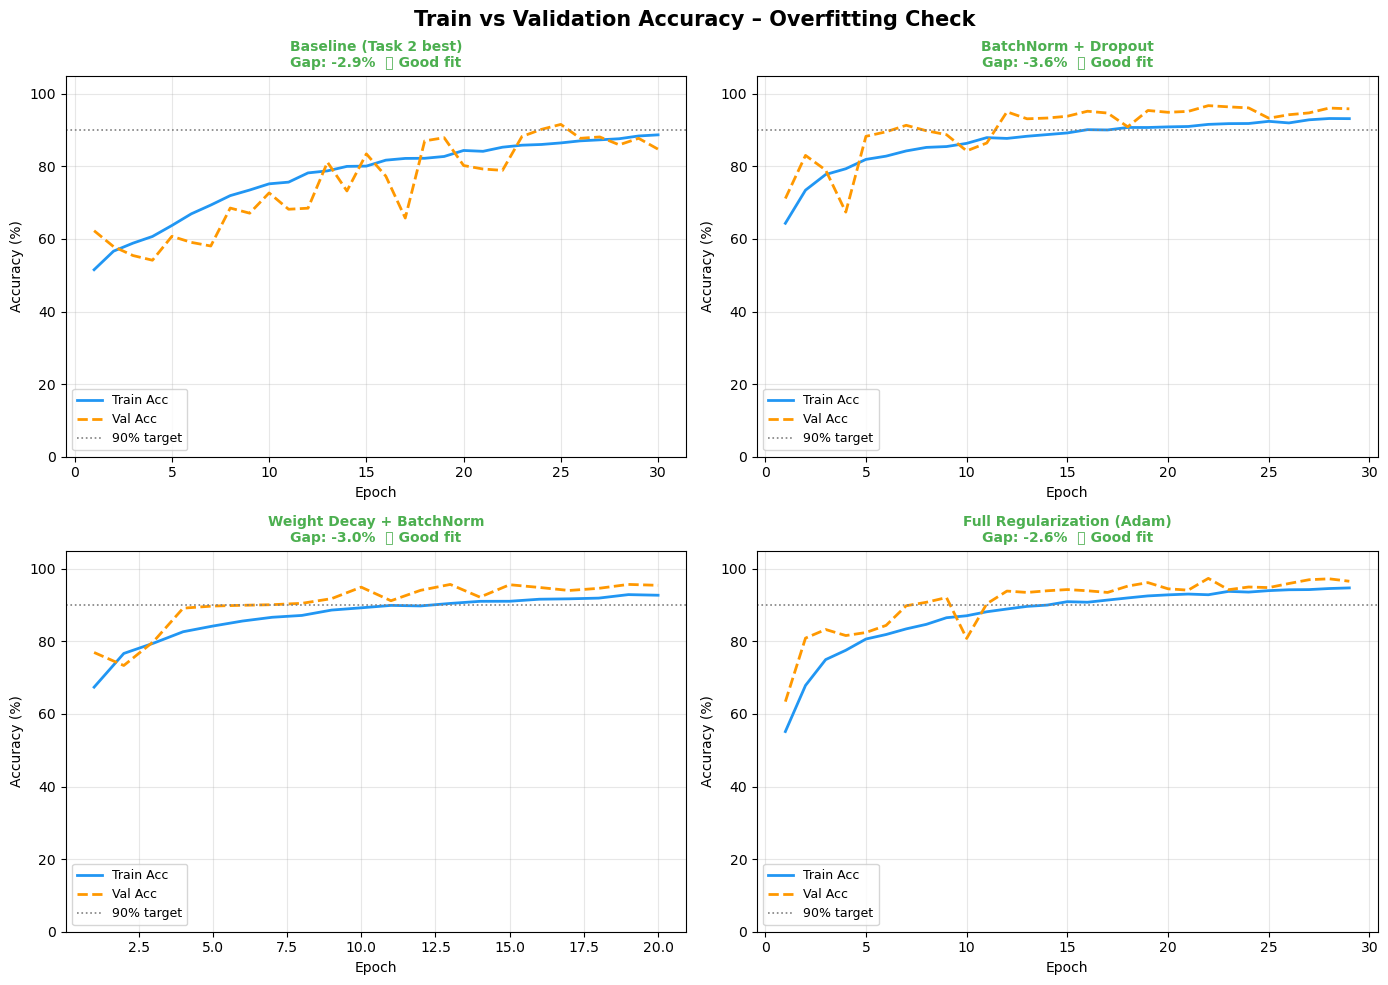

📊 Plot 10 saved → plot10_overfitting_check.png


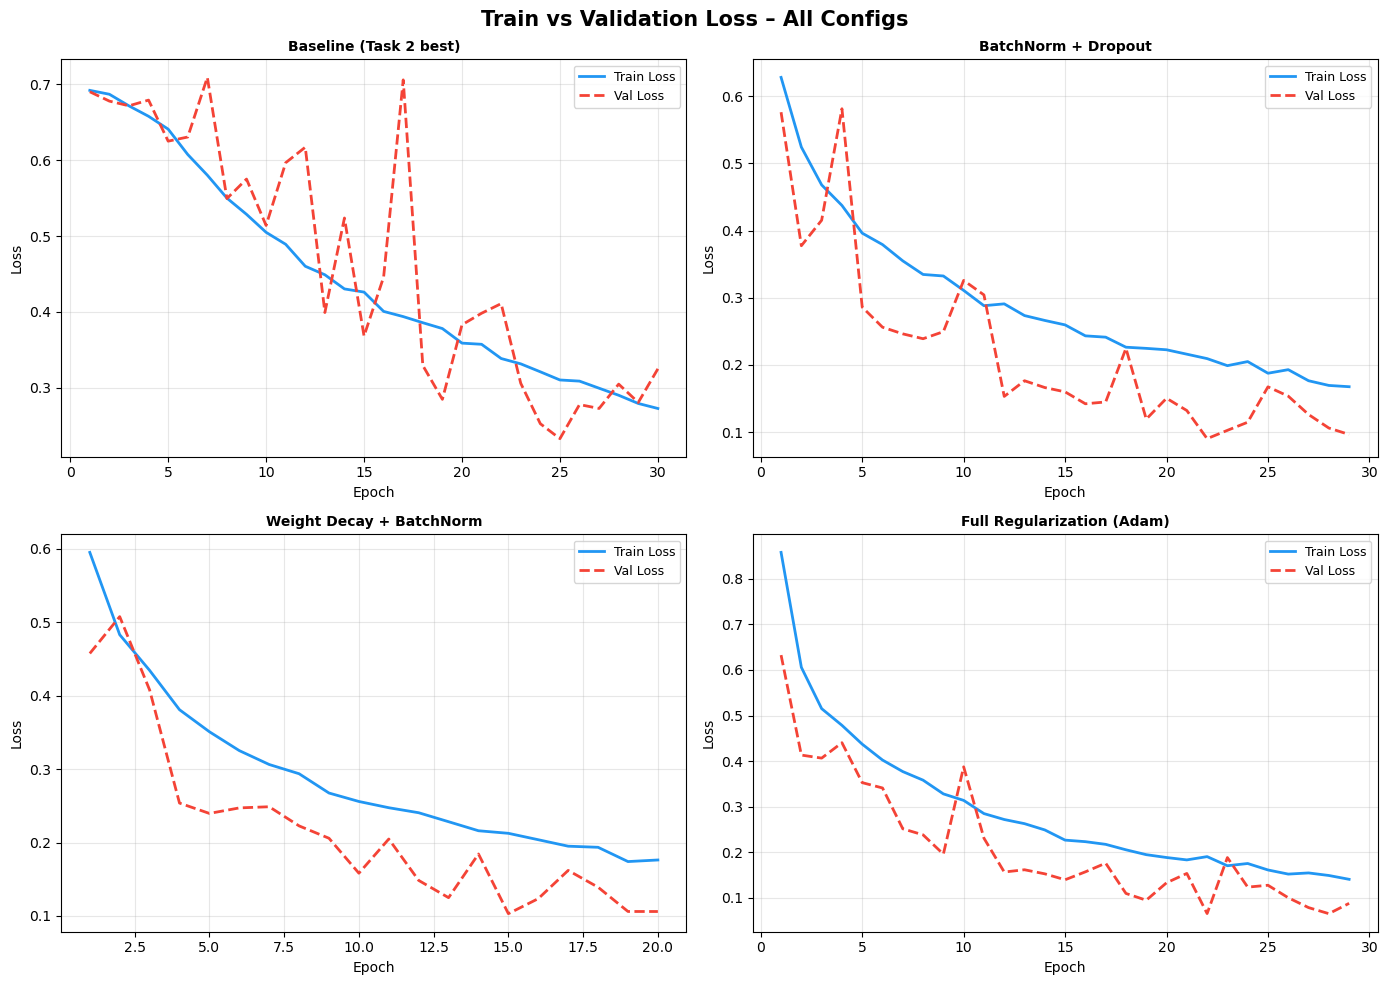

📊 Plot 11 saved → plot11_loss_curves.png


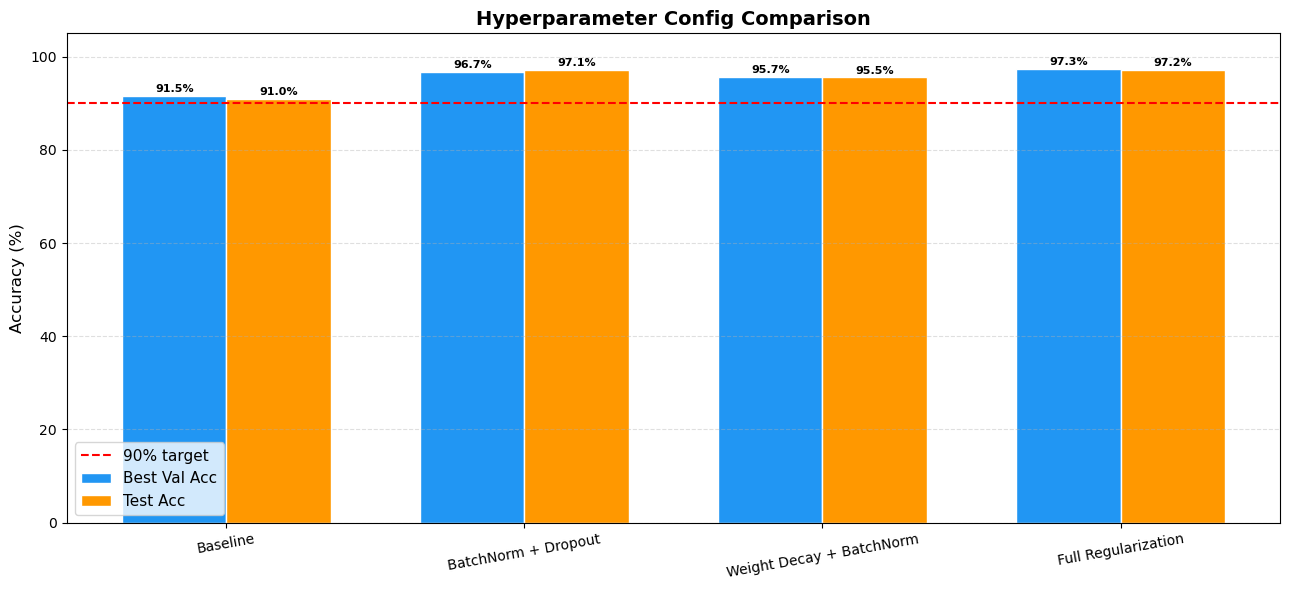

📊 Plot 12 saved → plot12_config_comparison.png


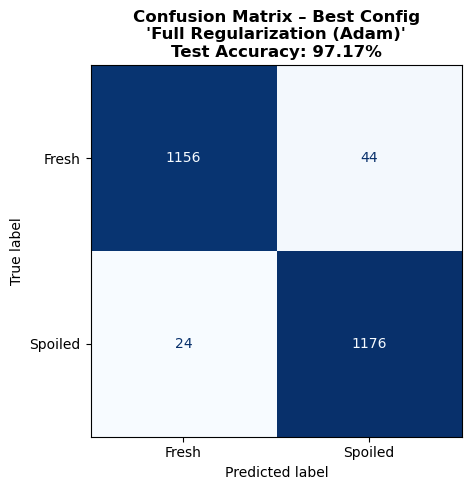

📊 Plot 13 saved → plot13_confusion_matrix_best.png


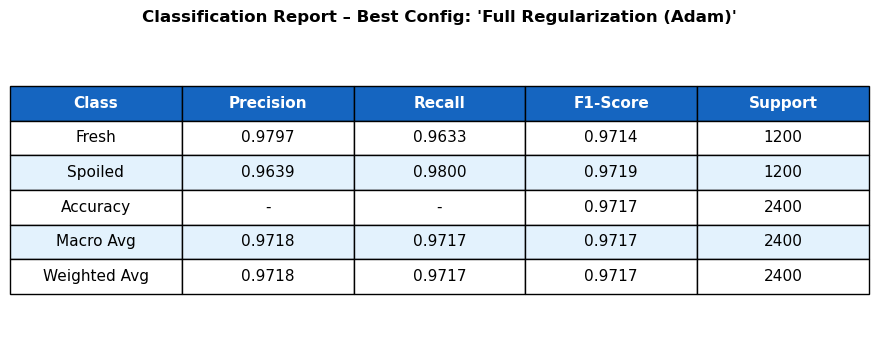

📊 Plot 14 saved → plot14_classification_report.png


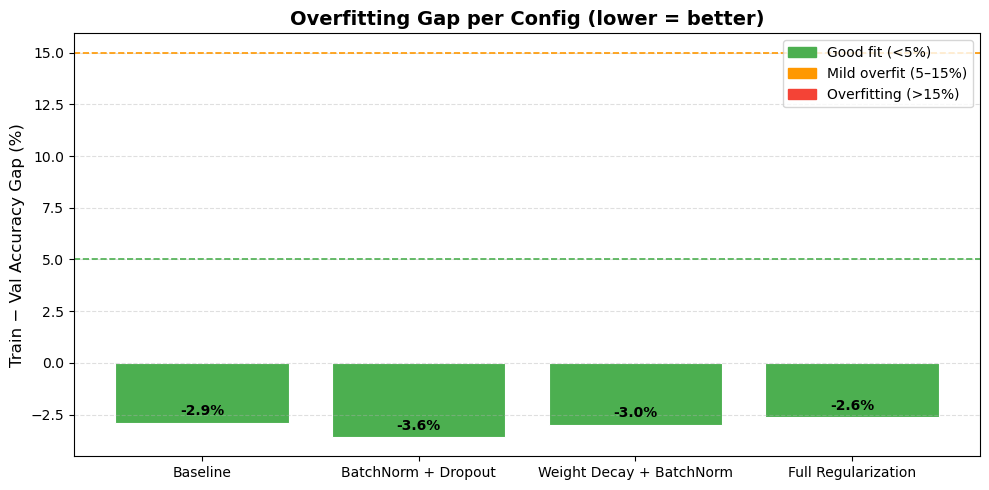

📊 Plot 15 saved → plot15_overfit_gap.png


In [11]:
# ─────────────────────────────────────────────
# 9. VISUALISATIONS
# ─────────────────────────────────────────────

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

# ── Plot 1: Overfitting check – Train vs Val accuracy ─────────
#    (Task requirement: plot train/val accuracy to check overfitting)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Train vs Validation Accuracy – Overfitting Check",
             fontsize=15, fontweight="bold")
axes = axes.flatten()

for i, (name, res) in enumerate(all_results.items()):
    h   = res["history"]
    eps = range(1, len(h["train_acc"]) + 1)
    ax  = axes[i]

    ax.plot(eps, h["train_acc"], label="Train Acc",
            color="#2196F3", linewidth=2)
    ax.plot(eps, h["val_acc"],   label="Val Acc",
            color="#FF9800", linewidth=2, linestyle="--")
    ax.axhline(90, color="grey", linestyle=":", linewidth=1.2,
               label="90% target")

    gap   = h["train_acc"][-1] - res["best_val_acc"]
    color = "#4CAF50" if gap < 5 else "#FF9800" if gap < 15 else "#F44336"
    ax.set_title(f"{name}\nGap: {gap:.1f}%  {res['overfit_status']}",
                 fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot10_overfitting_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot 10 saved → plot10_overfitting_check.png")


# ── Plot 2: Train vs Val Loss curves ──────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Train vs Validation Loss – All Configs",
             fontsize=15, fontweight="bold")
axes = axes.flatten()

for i, (name, res) in enumerate(all_results.items()):
    h   = res["history"]
    eps = range(1, len(h["train_loss"]) + 1)
    ax  = axes[i]

    ax.plot(eps, h["train_loss"], label="Train Loss",
            color="#2196F3", linewidth=2)
    ax.plot(eps, h["val_loss"],   label="Val Loss",
            color="#F44336", linewidth=2, linestyle="--")
    ax.set_title(f"{name}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plot11_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot 11 saved → plot11_loss_curves.png")


# ── Plot 3: Config comparison bar chart ───────────────────────
names     = list(all_results.keys())
val_accs  = [all_results[n]["best_val_acc"] for n in names]
test_accs = [all_results[n]["test_acc"]     for n in names]
x = np.arange(len(names))
w = 0.35
short_names = [n.split("(")[0].strip() for n in names]

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - w/2, val_accs,  w, label="Best Val Acc",
            color="#2196F3", edgecolor="white")
b2 = ax.bar(x + w/2, test_accs, w, label="Test Acc",
            color="#FF9800",  edgecolor="white")
ax.axhline(90, color="red", linestyle="--", linewidth=1.5, label="90% target")
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=10, rotation=10)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_ylim(0, 105)
ax.set_title("Hyperparameter Config Comparison",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
for bar, acc in zip(list(b1) + list(b2), val_accs + test_accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.4,
            f"{acc:.1f}%", ha="center", va="bottom",
            fontsize=8, fontweight="bold")
plt.tight_layout()
plt.savefig("plot12_config_comparison.png", dpi=150)
plt.show()
print("📊 Plot 12 saved → plot12_config_comparison.png")


# ── Plot 4: Confusion Matrix (best config) ────────────────────
cm   = confusion_matrix(best_result["test_labels"],
                        best_result["test_preds"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=BINARY_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(
    f"Confusion Matrix – Best Config\n'{best_name}'\n"
    f"Test Accuracy: {best_result['test_acc']:.2f}%",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("plot13_confusion_matrix_best.png", dpi=150)
plt.show()
print("📊 Plot 13 saved → plot13_confusion_matrix_best.png")


# ── Plot 5: Classification Report ─────────────────────────────
report = classification_report(
    best_result["test_labels"],
    best_result["test_preds"],
    target_names=BINARY_NAMES,
    output_dict=True,
)
rows = []
for cls in BINARY_NAMES + ["accuracy", "macro avg", "weighted avg"]:
    if cls == "accuracy":
        rows.append(["Accuracy", "-", "-",
                     f"{report[cls]:.4f}",
                     int(report["macro avg"]["support"])])
    else:
        rows.append([
            cls.title(),
            f"{report[cls]['precision']:.4f}",
            f"{report[cls]['recall']:.4f}",
            f"{report[cls]['f1-score']:.4f}",
            int(report[cls]["support"]),
        ])

col_labels = ["Class", "Precision", "Recall", "F1-Score", "Support"]
fig, ax    = plt.subplots(figsize=(9, 3.5))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=col_labels,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1565C0")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#E3F2FD")
ax.set_title(
    f"Classification Report – Best Config: '{best_name}'",
    fontsize=12, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig("plot14_classification_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Plot 14 saved → plot14_classification_report.png")


# ── Plot 6: Overfitting summary bar (gap comparison) ──────────
names_short = [n.split("(")[0].strip() for n in all_results.keys()]
gaps        = [all_results[n]["overfit_gap"] for n in all_results.keys()]
gap_colors  = ["#4CAF50" if g < 5
               else "#FF9800" if g < 15
               else "#F44336" for g in gaps]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names_short, gaps, color=gap_colors, edgecolor="white",
              linewidth=0.8)
ax.axhline(5,  color="#4CAF50", linestyle="--", linewidth=1.2,
           label="Good fit threshold (5%)")
ax.axhline(15, color="#FF9800", linestyle="--", linewidth=1.2,
           label="Overfit threshold (15%)")
for bar, gap in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"{gap:.1f}%", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_ylabel("Train − Val Accuracy Gap (%)", fontsize=12)
ax.set_title("Overfitting Gap per Config (lower = better)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
legend_patches = [
    mpatches.Patch(color="#4CAF50", label="Good fit (<5%)"),
    mpatches.Patch(color="#FF9800", label="Mild overfit (5–15%)"),
    mpatches.Patch(color="#F44336", label="Overfitting (>15%)"),
]
ax.legend(handles=legend_patches, fontsize=10)
plt.tight_layout()
plt.savefig("plot15_overfit_gap.png", dpi=150)
plt.show()
print("📊 Plot 15 saved → plot15_overfit_gap.png")

In [12]:
# ─────────────────────────────────────────────
# 10. FINAL SUMMARY
# ─────────────────────────────────────────────

print("\n" + "="*68)
print("         FRESHHARVEST – WEEK 1 TASK 3 SUMMARY")
print("="*68)
print(f"  Device         : {device}")
print(f"  Early Stopping : patience = {EARLY_STOP_PATIENCE} epochs")
print("-"*68)
print(f"  {'Config':<36} │ {'Val Acc':>8} │ {'Test Acc':>9} │ {'Gap':>7} │ Status")
print(f"  {'-'*36}─┼─{'─'*8}─┼─{'─'*9}─┼─{'─'*7}─┼────────")
for name, res in all_results.items():
    marker = " 🏆" if name == best_name else ""
    short  = name[:34]
    print(f"  {short:<36} │ {res['best_val_acc']:>7.2f}% │ "
          f"{res['test_acc']:>8.2f}% │ {res['overfit_gap']:>6.1f}% │ "
          f"{res['overfit_status']}{marker}")
print("-"*68)

target = ("✅ TARGET MET!" if best_result["test_acc"] >= 90
          else "⚠️  Below 90% – try more epochs")
print(f"\n  🏆 Best Config   : {best_name}")
print(f"     Val Accuracy  : {best_result['best_val_acc']:.2f}%")
print(f"     Test Accuracy : {best_result['test_acc']:.2f}%   {target}")
print(f"     Overfit Gap   : {best_result['overfit_gap']:.2f}%  "
      f"{best_result['overfit_status']}")
print(f"\n  💾 Saved to      : freshharvest_best_model.pt")
print("="*68)
print("\n✅ Week 1 Task 3 complete – Model is ready for deployment!\n")


         FRESHHARVEST – WEEK 1 TASK 3 SUMMARY
  Device         : cuda
  Early Stopping : patience = 7 epochs
--------------------------------------------------------------------
  Config                               │  Val Acc │  Test Acc │     Gap │ Status
  ------------------------------------─┼──────────┼───────────┼─────────┼────────
  Baseline (Task 2 best)               │   91.54% │    91.00% │   -2.9% │ ✅ Good fit
  BatchNorm + Dropout                  │   96.71% │    97.08% │   -3.6% │ ✅ Good fit
  Weight Decay + BatchNorm             │   95.67% │    95.54% │   -3.0% │ ✅ Good fit
  Full Regularization (Adam)           │   97.33% │    97.17% │   -2.6% │ ✅ Good fit 🏆
--------------------------------------------------------------------

  🏆 Best Config   : Full Regularization (Adam)
     Val Accuracy  : 97.33%
     Test Accuracy : 97.17%   ✅ TARGET MET!
     Overfit Gap   : -2.63%  ✅ Good fit

  💾 Saved to      : freshharvest_best_model.pt

✅ Week 1 Task 3 complete – Model is re